<a href="https://colab.research.google.com/github/tuantrangprod/tool.mobilegame.hotpotflow/blob/main/Hotpot_Flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotpot Flow
- backtracking level gen

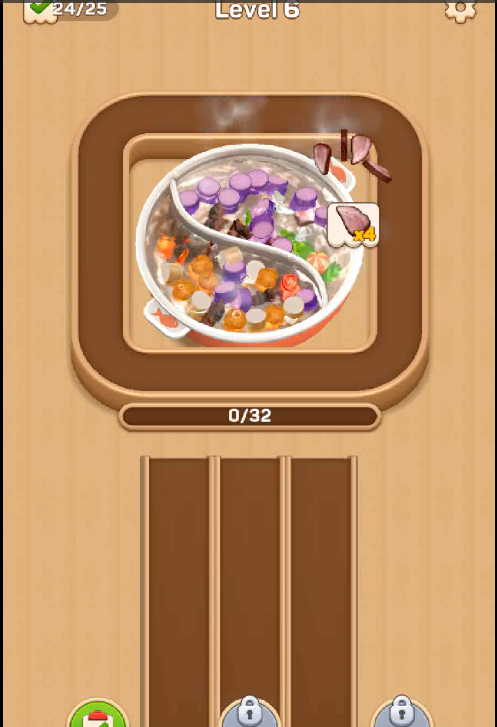

### Configs:
- lane:
  - Stack/queue of items
    - item.id
  - number of lane(s) in a level: 1 -> 4
  - User input:
      tap on a lane -> move 1 item from lane to loop
- target (hotpot):
  - 1-4 target(s)
  - each target = a stack
- loop (buffer):
  - 1 list
  - fixed slot
  - lose condition = full slot without any possible move from loop to target

### Details
#### Configs:
  Lanes (The Input): Vertical stacks (queues) containing the playable items. There are 1 to 4 lanes per level. Only a specific number of top items (e.g., the top 12) are visible to the player, hiding the items underneath. Items in lanes are grouped in varying quantities (2, 3, 4, 5, 6+).

  Loop (The Buffer): A circular waiting area with a hard limit of max_slots (e.g., 32 slots). This limit is fixed per level but can vary between different levels.

  Target (The Hotpot): 2 to 5 objective areas per level. Each target demands a specific quantity of unique item IDs (e.g., 4x Shrimp, 6x Egg). Order does not matter.

#### Basic Gameplay Logic
  Player Action: The player taps a Lane.

  Movement: The top item is popped from that Lane and placed into the Loop.

  Evaluation (Auto-Match): As the item travels the Loop, the system checks if it matches any required items for the active Targets.

  Resolution: * Match: If the item is needed, it automatically flies into the Target, decrementing the Target's requirement and freeing up that space in the Loop.

  No Match: If the item is not currently needed by any Target, it stays in the Loop, permanently occupying one of the max_slots until a matching Target becomes available (which might require clearing other Targets first).

  Win Condition
  The player successfully matches and moves enough items from the Lanes through the Loop to satisfy all item requirements for all Targets.

  Lose Condition (Buffer Overflow)
  The Loop reaches its absolute maximum capacity (loop.count == max_slots) AND none of the items currently sitting in the Loop can be used to satisfy the active Targets. The player is gridlocked and cannot pop any more items from the Lanes.

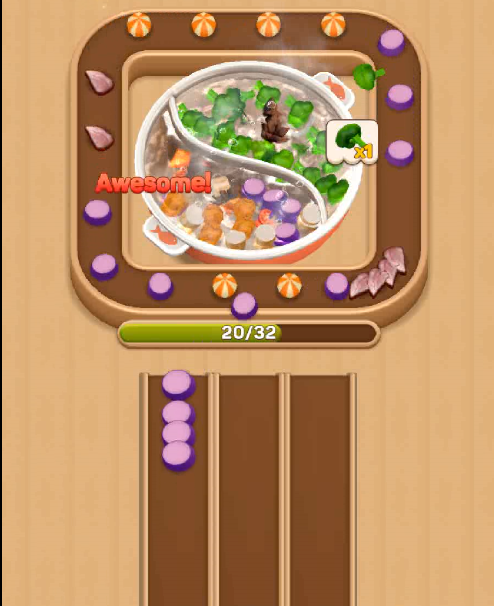

### puzzle logic:

#### Init:
  target: Shows the required items on top of the Stack
  loop: empty, shows the max slots
  lanes: shows top items
  
  lane -> loop -> target

#### move:
  selected_item = pop 1 item from selected lane
  if loop not max:
    place selected_item to loop
    if any loop.item match (target.required_items):
      move loop.item to target
      check win condtion
    else:
      check lose condition

### backtrack logic steps:

  target -> loop -> lane:
  target (full items) - move group items -> loop -> loop stack control (difficulty) - move group items -> lane

#### init: total_items

while total_items:
  pop x items from total_items # random group of either 2 or 3 items
  add x items to a random lane (stack FILO)
  add x items to a random target (stack)

In [6]:
'''
# Difficulty involvement:

## Loop stack control:
 the current target.top_item != loop.items # same meaning with the current target.top_item != lane(s).top_items

'''

'\n# Difficulty involvement:\n\n## Loop stack control:\n the current target.top_item != loop.items # same meaning with the current target.top_item != lane(s).top_items\n\n'

In [7]:
# main basic backtracking level gen sketch
import random
import copy # Needed to clone the game state

def generate_level_iterative(target_requirements, max_slots, num_lanes):
    # 1. Define the Initial State
    initial_state = {
        'targets_left': target_requirements.copy(), # e.g., [0, 1, 2, ...] # item_id
        'buffer': [],
        'lanes': [ [] for _ in range(num_lanes) ]
    }

    # 2. Initialize the DFS Stack
    dfs_stack = [initial_state]

    # 3. The Main Search Loop
    while dfs_stack:
        # Pop the most recent state (LIFO -> Depth First)
        current_state = dfs_stack.pop()

        # Win Condition Check
        if not current_state['targets_left'] and not current_state['buffer']:
            # We found a valid generation path!
            return current_state['lanes']

        # Find all valid moves from this exact state
        valid_next_states = []

        # Move A: Target -> Buffer (Un-solve)
        if current_state['targets_left'] and len(current_state['buffer']) < max_slots:
            # CREATE A CLONE OF THE STATE
            new_state = copy.deepcopy(current_state)
            item = new_state['targets_left'].pop()
            new_state['buffer'].append(item)
            valid_next_states.append(new_state)

        # Move B: Buffer -> Lane (Un-pop)
        if current_state['buffer']:
            # In a real game, you'd pick a random lane. Let's try all valid lanes.
            for lane_index in range(num_lanes):
                # Optional: check if lane reached max height here

                # CREATE A CLONE OF THE STATE
                new_state = copy.deepcopy(current_state)
                # Pick a random item from buffer to bury
                item_idx = random.randint(0, len(new_state['buffer']) - 1)
                item = new_state['buffer'].pop(item_idx)

                # Insert at index 0 (bottom-to-top building)
                new_state['lanes'][lane_index].insert(0, item)
                valid_next_states.append(new_state)

        # Shuffle the valid next states to ensure randomness, then push to stack
        random.shuffle(valid_next_states)
        for state in valid_next_states:
            dfs_stack.append(state)

    # If the while loop finishes and we never returned, it's impossible.
    return "Generation Failed - No valid path found."

In [11]:
import IPython

def draw_flowchart():
    # Use LR (Left-to-Right) so it's not too tall
    mermaid_code = """
graph LR
    Start((Start Gen)) --> StackCheck{Search Stack Empty?}
    StackCheck -- Yes --> Fail((FAILED))
    StackCheck -- No --> PopState[Pop State]
    PopState --> WinCheck{Targets Empty?}
    WinCheck -- Yes --> Success((SOLVED))
    WinCheck -- No --> MoveCheck{Dead End?}
    MoveCheck -- Yes --> Prune[Discard Branch]
    MoveCheck -- No --> ApplyMove[Apply Moves]
    ApplyMove --> PushNext[Push Next]
    PushNext --> StackCheck
"""
    
    # Use transform: scale to shrink the size of the graph
    html_code = f"""
    <div class="mermaid" style="width: 150%; display: flex; justify-content: flex-start; transform: scale(1); transform-origin: top left; margin: 10px;">
        {mermaid_code}
    </div>
    <script src="https://cdn.jsdelivr.net/npm/mermaid@10.9.5/dist/mermaid.min.js"></script>
    <script>
        // Initialize mermaid if not already loaded in the notebook
        if (window.mermaid) {{
            mermaid.contentLoaded();
        }} else {{
            const script = document.querySelector('script[src*="mermaid"]');
            script.onload = () => {{
                mermaid.initialize({{ startOnLoad: true, theme: 'default' }});
            }};
        }}
    </script>
    """
    return IPython.display.HTML(html_code)

draw_flowchart()


In [ ]:
game_state = {'target': [],
              'loop': [],
              'lane': []}
              



In [ ]:
# hard difficulty:
# -> have to move x items to loop
# -> to be able to tap required items

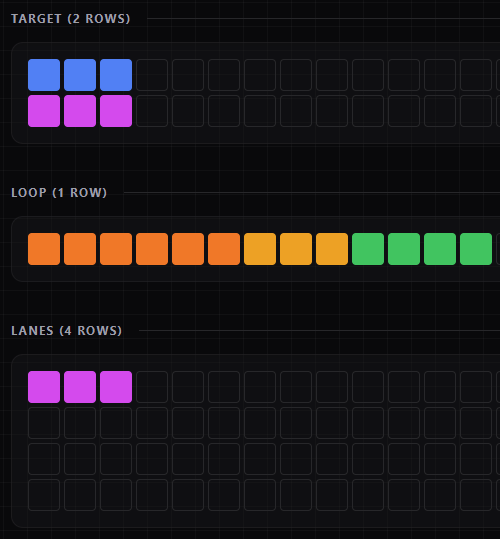

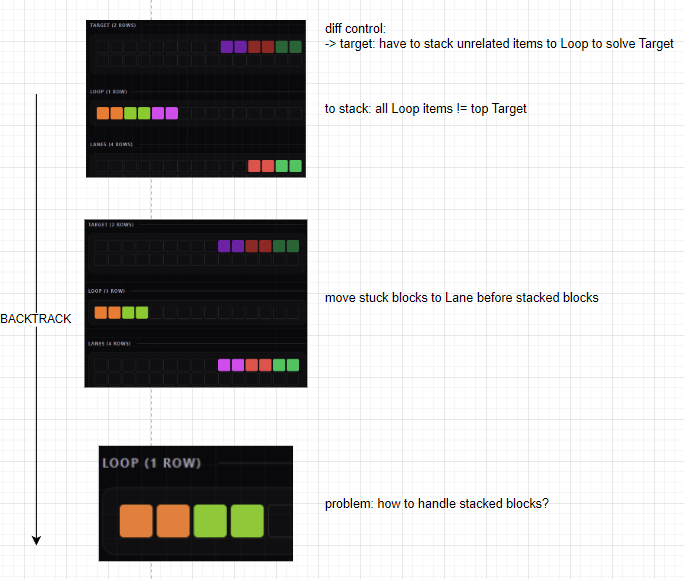